# 17: Common Pitfalls, Reporting, and Limitations

This closing notebook is about the habits that keep causal discovery work honest. Earlier notebooks showed how to run PC, FCI, GES, LiNGAM, functional causal models, permutation methods, time-series methods, hidden-representation ideas, benchmarks, and an end-to-end case study. We ask a different question: after you can run these algorithms, how do you avoid overclaiming what the output graph means?

Causal discovery is powerful because it can surface candidate structure from data. It is risky because the algorithms are only as good as their assumptions, variable design, measurement timing, sample size, and validation workflow. A polished graph can still be wrong if it was learned from biased data, if hidden common causes were ignored, if post-outcome variables leaked into the feature set, or if unstable edges were reported as facts.

The goal here is not to make you pessimistic. The goal is to make you precise. A good causal discovery report says what was searched, what assumptions were made, what changed under sensitivity checks, which edges were stable, which edges require domain review, and what downstream validation should happen next.

Estimated runtime: about 1 to 2 minutes on a typical laptop. The examples use small synthetic datasets so the notebook stays fast and reproducible.

## Learning Goals

By the end, you should be able to:

- recognize hidden-confounding risk when a discovered adjacency has a plausible omitted common cause;
- see why small samples and weak effects make graph recovery unstable;
- explain why many graph directions are not identifiable from conditional independence alone;
- detect temporal leakage and post-outcome variables before they enter a discovery run;
- demonstrate selection bias from conditioning on a collider;
- flag near-duplicate measurements that can create cluttered or misleading graphs;
- write reports that treat discovered graphs as candidate structures rather than finished causal proof.

## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use synthetic graph-discovery datasets with known structural equations and known graph truth to study **Common Pitfalls, Reporting, And Limitations**. Known graph truth lets us see when an algorithm recovers edges, misses edges, or invents edges under violated assumptions.

Read each row as a draw from a structural causal system. Columns are observed variables, and in some notebooks omitted latent variables, environments, time ordering, or non-Gaussian mechanisms are deliberately introduced. The examples are failure cases by design. They are included so readers learn how plausible causal workflows break in practice. The examples connect diagnostics to reporting. A good report states what the data can support and where the design remains vulnerable.

The goal is to learn what each discovery method assumes and how its output should be audited.


## Mathematical Foundation

<!-- math-foundation-note -->

Causal discovery produces an estimated graph $\widehat G$. A compact benchmark compares it with a reference graph $G$ through structural Hamming distance,

$$
\operatorname{SHD}(\widehat G,G)=\text{edge additions}+\text{edge deletions}+\text{edge reversals}.
$$

Stability can be summarized by a bootstrap edge frequency,

$$
\widehat\pi_{ij}=\frac{1}{B}\sum_{b=1}^{B}\mathbf{1}\{i\rightarrow j\in\widehat G_b\}.
$$

The reporting goal is to show which edges are stable, which assumptions matter, and which conclusions remain tentative.



The notebook moves from setup to reusable helpers and then through six practical failure-mode labs:

1. hidden confounding can create convincing but incomplete observed graphs;
2. weak tests and small samples can make edge recovery highly variable;
3. Markov-equivalent graphs can share the same conditional-independence evidence;
4. temporal leakage can smuggle future information into a discovery task;
5. selection bias can create dependence where no direct causal link exists;
6. near-duplicate measurements can dominate a learned graph.

The final section turns these examples into a reporting checklist and a reusable graph-discovery report template.




## Tutorial Workflow

#### Setup

The code below imports the scientific Python stack, prepares the output folders, configures Matplotlib to write cache files inside the repository, and imports the causal-learn algorithms used in the examples. Progress bars are disabled in algorithm calls later so the notebook stays clean when executed end to end.

In [1]:
# Build and label the diagnostic visualization for the Setup section.
from pathlib import Path
import os
import time
import warnings

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "causal_learn":
    REPO_ROOT = REPO_ROOT.parents[2]

OUTPUT_DIR = REPO_ROOT / "notebooks" / "tutorials" / "causal_learn" / "outputs"
DATASET_DIR = OUTPUT_DIR / "datasets"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
REPORT_DIR = OUTPUT_DIR / "reports"
MATPLOTLIB_CACHE_DIR = OUTPUT_DIR / "matplotlib_cache"

for directory in [DATASET_DIR, FIGURE_DIR, TABLE_DIR, REPORT_DIR, MATPLOTLIB_CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(MATPLOTLIB_CACHE_DIR))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="IProgress not found.*")

import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from IPython.display import display, Markdown
from sklearn.preprocessing import StandardScaler

import causallearn
from causallearn.search.ConstraintBased.PC import pc
from causallearn.search.ConstraintBased.FCI import fci

NOTEBOOK_PREFIX = "17"
RANDOM_SEED = 42
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 160})

print(f"Repository root: {REPO_ROOT}")
print(f"Outputs: {OUTPUT_DIR}")


Repository root: /home/apex/Documents/portfolio
Outputs: /home/apex/Documents/portfolio/notebooks/tutorials/causal_learn/outputs


The setup cell creates the same output structure used by the rest of the causal-learn tutorial. Keeping figures, tables, datasets, and reports under one `outputs` folder makes the notebook easy to rerun and easy to audit later.

#### Package Versions

A causal discovery result depends on algorithm implementations and default settings. The code below records the package versions used for the tutorial run so that saved outputs can be traced back to the environment that created them.

In [2]:
import sklearn

version_table = pd.DataFrame(
    [
        {"package": "numpy", "version": np.__version__},
        {"package": "pandas", "version": pd.__version__},
        {"package": "scikit-learn", "version": sklearn.__version__},
        {"package": "causal-learn", "version": getattr(causallearn, "__version__", "not exposed")},
    ]
)
version_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_package_versions.csv", index=False)
display(version_table)

,package,version
0,numpy,2.4.4
1,pandas,3.0.2
2,scikit-learn,1.6.1
3,causal-learn,not exposed


This table is small, but it belongs in serious reports. If an edge changes after a package upgrade, the version table helps separate a real data change from an implementation or default-setting change.




## Reporting and Takeaways

### Pitfall Map

Before running examples, we list the major failure modes covered in this lesson. The map links each pitfall to a diagnostic habit and a reporting habit. This is the mental checklist to keep beside any causal discovery graph.

| pitfall | what_goes_wrong | diagnostic_habit | reporting_habit |
| --- | --- | --- | --- |
| Hidden confounding | Observed variables can be connected because they share an omitted cause. | Compare PC-style output with FCI-style latent-risk output and review omitted-cause stories. | Call the edge an observed-data candidate, not proof of direct causation. |
| Weak tests and small samples | Conditional-independence tests miss true weak links or add noisy links. | Run sample-size, alpha, and bootstrap sensitivity checks. | Report stable and unstable edge groups separately. |
| Over-orientation | Several DAGs can imply the same observable independence pattern. | Distinguish skeleton evidence from direction evidence. | Use cautious language for directions that come from assumptions rather than data alone. |
| Temporal leakage | Post-outcome variables can make the graph look predictive but invalid for causal reasoning. | Build a measurement-time table before discovery. | State the time window for every variable used in the graph. |
| Selection bias | Filtering on a collider can induce dependence between unrelated causes. | Compare full-population and selected-sample associations when possible. | Document the sampling rule and who is excluded. |
| Near-duplicate measurements | Multiple proxies for the same construct can crowd the graph with measurement edges. | Check high correlations, duplicate definitions, and shared feature engineering. | Collapse or label measurement families before reading them as causal mechanisms. |


The theme across the map is simple: discovery output needs context. A graph without assumptions, data provenance, and sensitivity checks is closer to a hypothesis sketch than a decision-ready causal object.



### Reusable Graph and Evaluation Helpers

The next cell defines small helpers used throughout the notebook. The graph drawing helper follows the same visual style used across this tutorial: wide white canvas, rounded pastel boxes, bold labels, and dark arrows that stop before the boxes so arrowheads remain visible.

In [3]:
# Define reusable helpers for the Reusable Graph And Evaluation Helpers section.
def trim_edge_to_box(start, end, box_w=0.16, box_h=0.09, gap=0.012):
    """
    Shorten an edge so arrows land outside rounded boxes rather than under labels.
    
    Parameters
    ----------
    start : tuple[float, float]
        Starting coordinate of the arrow or edge segment.
    end : tuple[float, float]
        Ending coordinate of the arrow or edge segment.
    box_w : float
        Width of the node box used to trim edge endpoints.
    box_h : float
        Height of the node box used to trim edge endpoints.
    gap : float
        Extra spacing between an edge endpoint and a node boundary.
    
    Returns
    -------
    tuple[tuple[float, float], tuple[float, float]]
        Start and end coordinates trimmed so the edge stops at box boundaries.
    """
    x0, y0 = start
    x1, y1 = end
    dx = x1 - x0
    dy = y1 - y0
    distance = (dx**2 + dy**2) ** 0.5
    if distance == 0:
        return start, end
    ux, uy = dx / distance, dy / distance
    candidates = []
    if abs(ux) > 1e-9:
        candidates.append((box_w / 2) / abs(ux))
    if abs(uy) > 1e-9:
        candidates.append((box_h / 2) / abs(uy))
    offset = min(candidates) + gap
    return (x0 + ux * offset, y0 + uy * offset), (x1 - ux * offset, y1 - uy * offset)


def draw_box_graph(edge_df, node_specs, title, path, note=None, highlight_edges=None):
    """
    Draw a compact causal graph using the notebook's rounded-box figure style.
    
    Parameters
    ----------
    edge_df : pd.DataFrame
        Learned or oracle edge table being summarized or drawn.
    node_specs : object
        Node-position and label specifications used to draw the graph.
    title : str
        Title shown above the plot or saved artifact.
    path : str or pathlib.Path
        Output path where the figure or artifact is saved.
    note : str or None
        Optional explanatory note shown in the plot.
    highlight_edges : pd.DataFrame or collection
        Edges associated with `highlight`.
    
    Returns
    -------
    None
        Draws the graph diagram directly on the Matplotlib axes and saves it when requested.
    """
    highlight_edges = highlight_edges or set()
    fig, ax = plt.subplots(figsize=(14, 6.5))
    ax.set_axis_off()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    for row in edge_df.itertuples(index=False):
        if row.source not in node_specs or row.target not in node_specs:
            continue
        start, end = trim_edge_to_box(node_specs[row.source]["xy"], node_specs[row.target]["xy"])
        edge_type = getattr(row, "edge_type", "-->")
        edge_key = (row.source, row.target)
        color = "#7c3aed" if edge_key in highlight_edges else "#334155"
        arrowstyle = "-|>" if edge_type == "-->" else "-"
        linestyle = "--" if edge_type in {"o-o", "<->"} else "solid"
        linewidth = 2.4 if edge_key in highlight_edges else 1.8
        arrow = FancyArrowPatch(
            start,
            end,
            arrowstyle=arrowstyle,
            mutation_scale=18,
            linewidth=linewidth,
            color=color,
            linestyle=linestyle,
            connectionstyle="arc3,rad=0.035",
            zorder=2,
        )
        ax.add_patch(arrow)

    for variable, spec in node_specs.items():
        x, y = spec["xy"]
        rect = FancyBboxPatch(
            (x - 0.082, y - 0.046),
            0.164,
            0.092,
            boxstyle="round,pad=0.014",
            facecolor=spec.get("color", "#dbeafe"),
            edgecolor="#1f2937",
            linewidth=1.15,
            zorder=4,
        )
        ax.add_patch(rect)
        ax.text(x, y, spec.get("label", variable), ha="center", va="center", fontsize=9.8, fontweight="bold", zorder=5)

    if note:
        ax.text(0.5, 0.07, note, ha="center", va="center", fontsize=10, color="#475569")
    ax.set_title(title, pad=16, fontsize=16, fontweight="bold")
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()


def make_edge_table(edges, run="manual"):
    """
    Idea: Construct the edge table used in the Reusable Graph And Evaluation Helpers section, including columns needed for later diagnostics.
    
    Parameters
    ----------
    edges : object
        Collection of graph edges to draw, compare, or convert into a table.
    run : object
        Run index used to label a repeated simulation or benchmark.
    
    Returns
    -------
    pd.DataFrame
        Dataset table for make edge table, with the variables needed by the tutorial design.
    """
    return pd.DataFrame(
        [{"run": run, "source": source, "edge_type": edge_type, "target": target} for source, edge_type, target in edges],
        columns=["run", "source", "edge_type", "target"],
    )


def parse_causallearn_edge(edge):
    """
    Idea: Convert a causal-learn graph edge object into plain endpoint labels for tabular auditing.
    
    Parameters
    ----------
    edge : object
        Single graph edge being parsed, drawn, or evaluated.
    
    Returns
    -------
    tuple[str, str, str]
        Source node, endpoint mark, and target node parsed from a causal-learn edge.
    """
    text = str(edge).strip()
    edge_tokens = [" --> ", " <-- ", " <-> ", " o-> ", " <-o ", " o-o ", " --- "]
    for token in edge_tokens:
        if token in text:
            left, right = text.split(token)
            if token == " <-- ":
                return {"source": right.strip(), "edge_type": "-->", "target": left.strip()}
            if token == " <-o ":
                return {"source": right.strip(), "edge_type": "o->", "target": left.strip()}
            return {"source": left.strip(), "edge_type": token.strip(), "target": right.strip()}
    raise ValueError(f"Could not parse edge: {text}")


def graph_to_edge_table(graph, label):
    """
    Idea: Convert a causal-learn graph object into a DataFrame of edge endpoints and method labels.
    
    Parameters
    ----------
    graph : object
        Graph object returned by the causal discovery or causal modeling library.
    label : str
        Short label attached to a scenario, method, or plotted result.
    
    Returns
    -------
    pd.DataFrame
        Edge table with source, target, edge mark, and method metadata.
    """
    rows = [parse_causallearn_edge(edge) for edge in graph.get_graph_edges()]
    edge_table = pd.DataFrame(rows, columns=["source", "edge_type", "target"])
    edge_table.insert(0, "run", label)
    return edge_table


def standardize_frame(df):
    """
    Idea: Compute the frame needed in the Reusable Graph And Evaluation Helpers section and return it in a form the next cells can inspect.
    
    Parameters
    ----------
    df : pd.DataFrame
        Rows used by this helper.
    
    Returns
    -------
    pd.DataFrame
        Standardized copy of the input DataFrame with the original column names preserved.
    """
    return pd.DataFrame(StandardScaler().fit_transform(df), columns=df.columns)


def run_pc_edges(df, alpha=0.05, label="PC"):
    """
    Idea: Run PC and convert the learned graph into a comparable edge table.
    
    Parameters
    ----------
    df : pd.DataFrame
        Rows used by this helper.
    alpha : float
        Significance level, transparency value, or tuning parameter used by the diagnostic.
    label : str
        Short label attached to a scenario, method, or plotted result.
    
    Returns
    -------
    pd.DataFrame
        Edge table recovered by PC for the requested dataset.
    """
    started = time.perf_counter()
    graph = pc(
        df.to_numpy(),
        alpha=alpha,
        indep_test="fisherz",
        stable=True,
        verbose=False,
        show_progress=False,
        node_names=list(df.columns),
    ).G
    elapsed = time.perf_counter() - started
    return graph_to_edge_table(graph, label), elapsed


def run_fci_edges(df, alpha=0.05, label="FCI"):
    """
    Idea: Run FCI and convert the learned graph into a comparable edge table.
    
    Parameters
    ----------
    df : pd.DataFrame
        Rows used by this helper.
    alpha : float
        Significance level, transparency value, or tuning parameter used by the diagnostic.
    label : str
        Short label attached to a scenario, method, or plotted result.
    
    Returns
    -------
    pd.DataFrame
        Edge table recovered by FCI for the requested dataset.
    """
    started = time.perf_counter()
    graph, _ = fci(
        df.to_numpy(),
        independence_test_method="fisherz",
        alpha=alpha,
        verbose=False,
        show_progress=False,
        node_names=list(df.columns),
    )
    elapsed = time.perf_counter() - started
    return graph_to_edge_table(graph, label), elapsed


def skeleton_pairs(edge_df):
    """
    Idea: Reduce an edge table to unordered node pairs so skeleton recovery can be evaluated.
    
    Parameters
    ----------
    edge_df : pd.DataFrame
        Graph edges or edge-level diagnostics to summarize.
    
    Returns
    -------
    set[tuple[str, str]]
        Unordered node pairs representing the learned graph skeleton.
    """
    if edge_df.empty:
        return set()
    return {tuple(sorted((row.source, row.target))) for row in edge_df.itertuples(index=False)}


def directed_pairs(edge_df):
    """
    Idea: Extract directed edge pairs from an edge table so orientation recovery can be evaluated.
    
    Parameters
    ----------
    edge_df : pd.DataFrame
        Graph edges or edge-level diagnostics to summarize.
    
    Returns
    -------
    set[tuple[str, str]]
        Ordered source-target pairs representing directed learned edges.
    """
    if edge_df.empty:
        return set()
    return {(row.source, row.target) for row in edge_df.itertuples(index=False) if row.edge_type == "-->"}


These helpers keep later cells focused on the lesson rather than notebook plumbing. In particular, the graph parser turns causal-learn edge objects into a tabular format that can be saved, filtered, compared, and reported.



### Lab 1: Hidden Confounding

The first failure mode is an omitted common cause. In the synthetic truth below, `latent_need` affects both `discovery_quality` and `retention_value`. The observed dataset leaves `latent_need` out. That means an algorithm may connect the two observed variables even if the strongest story is shared upstream context rather than a clean direct effect.

This is the classic reason to treat an observed edge as a candidate path, not automatic proof of direct causation.

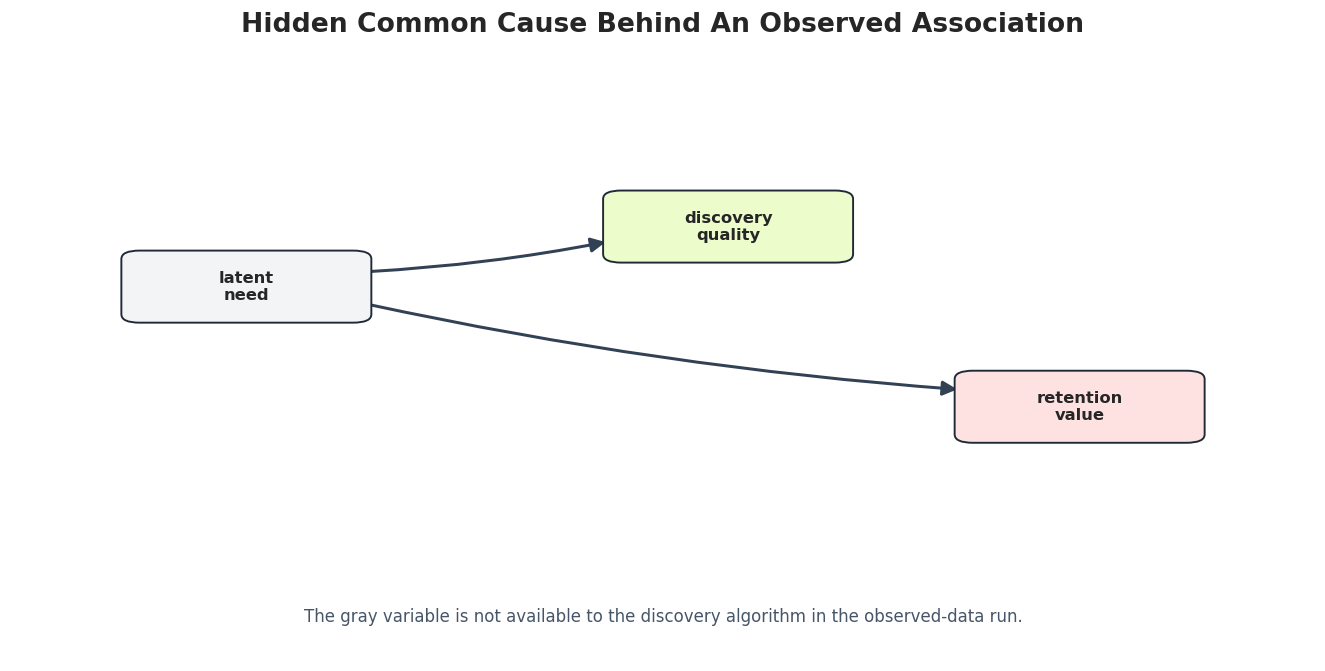

In [4]:
hidden_specs = {
    "latent_need": {"xy": (0.18, 0.62), "label": "latent\nneed", "color": "#f3f4f6"},
    "discovery_quality": {"xy": (0.55, 0.72), "label": "discovery\nquality", "color": "#ecfccb"},
    "retention_value": {"xy": (0.82, 0.42), "label": "retention\nvalue", "color": "#fee2e2"},
}
hidden_truth_edges = make_edge_table(
    [
        ("latent_need", "-->", "discovery_quality"),
        ("latent_need", "-->", "retention_value"),
    ],
    run="hidden_truth",
)
hidden_truth_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_hidden_confounding_truth_edges.csv", index=False)

draw_box_graph(
    hidden_truth_edges,
    hidden_specs,
    "Hidden Common Cause Behind An Observed Association",
    FIGURE_DIR / f"{NOTEBOOK_PREFIX}_hidden_confounding_truth.png",
    note="The gray variable is not available to the discovery algorithm in the observed-data run.",
)


The graph shows why hidden common causes are not a minor detail. If the gray variable is missing from the data, the observed variables can look causally close even when the underlying structure is incomplete.

Now we simulate the observed data. We keep only `discovery_quality` and `retention_value`, even though both were generated from the omitted `latent_need`. This reproduces a common real workflow: a dataset contains outcomes and intermediate measures, but not all upstream causes that generated them.

In [5]:
# Define reusable helpers for the Lab 1: Hidden Confounding section.
def simulate_hidden_confounding(n_samples=900, seed=RANDOM_SEED):
    """
    Idea: Simulate the hidden confounding scenario so the notebook can study a known causal or statistical failure mode.
    
    Parameters
    ----------
    n_samples : int
        Number of sampled rows or simulated units.
    seed : int
        Random seed used to make generation or resampling reproducible.
    
    Returns
    -------
    tuple
        Tuple containing standardize_frame(full_df), standardize_frame(observed_df).
    """
    rng = np.random.default_rng(seed)
    latent_need = rng.normal(size=n_samples)
    discovery_quality = 0.85 * latent_need + rng.normal(scale=0.75, size=n_samples)
    retention_value = 0.90 * latent_need + rng.normal(scale=0.75, size=n_samples)
    full_df = pd.DataFrame(
        {
            "latent_need": latent_need,
            "discovery_quality": discovery_quality,
            "retention_value": retention_value,
        }
    )
    observed_df = full_df[["discovery_quality", "retention_value"]].copy()
    return standardize_frame(full_df), standardize_frame(observed_df)

hidden_full_df, hidden_observed_df = simulate_hidden_confounding()
hidden_full_df.to_csv(DATASET_DIR / f"{NOTEBOOK_PREFIX}_hidden_confounding_full_data.csv", index=False)
hidden_observed_df.to_csv(DATASET_DIR / f"{NOTEBOOK_PREFIX}_hidden_confounding_observed_data.csv", index=False)

display(hidden_observed_df.head())
print(f"Observed data shape: {hidden_observed_df.shape}")


,discovery_quality,retention_value
0,0.540799,0.256163
1,-0.648177,-0.474094
2,0.519812,0.430525
3,1.800728,0.509854
4,-1.801804,-1.405639


Observed data shape: (900, 2)


The observed data has only two columns, so no purely observational algorithm can recover the missing gray node. The best we can do from this dataset alone is detect a strong association and then be explicit about omitted-cause risk.

The next cell compares PC and FCI on the observed two-variable dataset. FCI is designed to be more cautious when latent confounding may exist, although with only two observed variables it still cannot name the hidden cause. The point is to compare the edge language, not to expect magic recovery of a variable that was never measured.

In [6]:
hidden_pc_edges, hidden_pc_elapsed = run_pc_edges(hidden_observed_df, alpha=0.01, label="PC_observed_only")
hidden_fci_edges, hidden_fci_elapsed = run_fci_edges(hidden_observed_df, alpha=0.01, label="FCI_observed_only")

hidden_observed_edges = pd.concat([hidden_pc_edges, hidden_fci_edges], ignore_index=True)
hidden_observed_edges["elapsed_seconds"] = hidden_observed_edges["run"].map(
    {"PC_observed_only": hidden_pc_elapsed, "FCI_observed_only": hidden_fci_elapsed}
)
hidden_observed_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_hidden_confounding_observed_edges.csv", index=False)
display(hidden_observed_edges)

,run,source,edge_type,target,elapsed_seconds
0,PC_observed_only,discovery_quality,---,retention_value,0.001718
1,FCI_observed_only,discovery_quality,o-o,retention_value,0.000876


The learned edge is an observed-data clue. It should trigger the question, "what upstream variables could cause both sides?" rather than the statement, "the left side directly causes the right side."

A useful report makes the hidden-confounding concern visible. The code below writes a compact risk note that can be reused in the final report template.

| edge_or_pattern | observed_evidence | main_risk | responsible_next_step |
| --- | --- | --- | --- |
| discovery_quality connected to retention_value | Strong dependence remains in the observed dataset. | The association can be generated by omitted latent_need. | Measure richer pre-exposure context or validate the edge with an intervention or quasi-experiment. |


The note is deliberately plain. Discovery work becomes more useful when every high-risk edge is paired with a validation plan.

For causal discovery, the result is a statement about recoverable structure under assumptions, not a free-standing proof of cause and effect.
<!-- result-implication-expanded -->




### Lab 2: Weak Tests and Small Samples

Constraint-based algorithms depend on conditional-independence tests. When effects are weak or samples are small, these tests can fail in both directions: they can miss true adjacencies, and they can keep noisy adjacencies. This lab simulates the same true graph across sample sizes and alpha values so we can see how recovery changes.

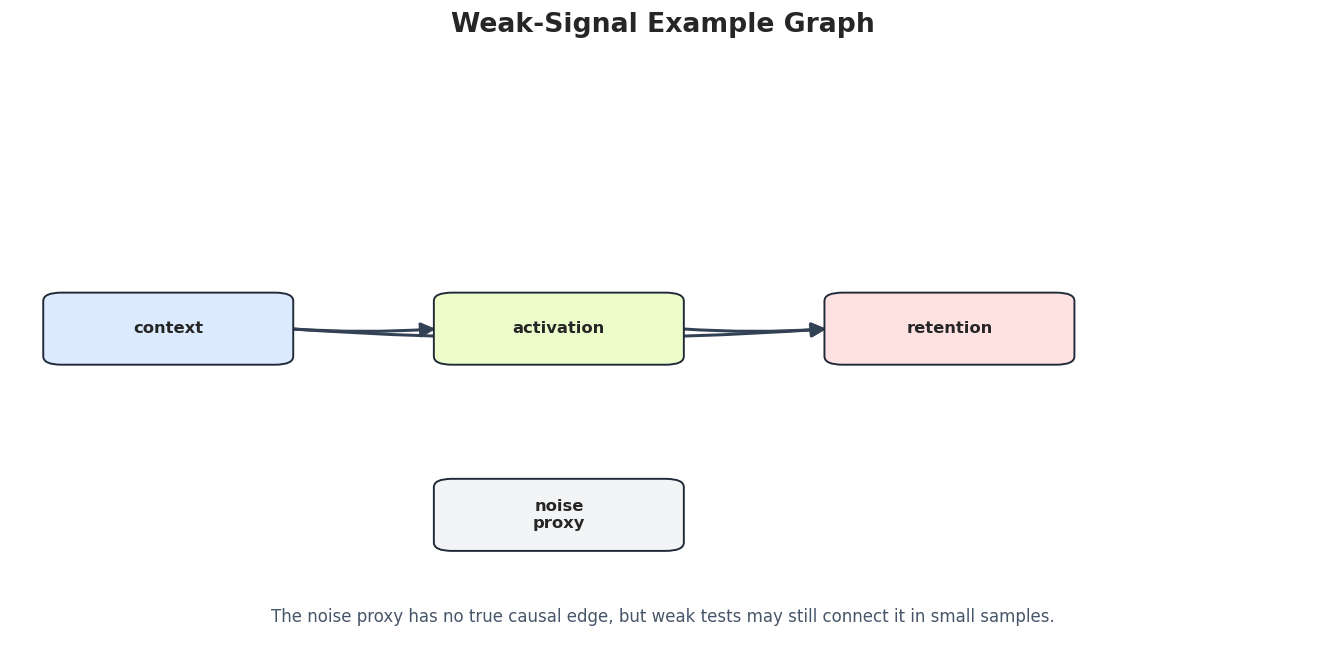

In [7]:
weak_specs = {
    "context": {"xy": (0.12, 0.55), "label": "context", "color": "#dbeafe"},
    "activation": {"xy": (0.42, 0.55), "label": "activation", "color": "#ecfccb"},
    "retention": {"xy": (0.72, 0.55), "label": "retention", "color": "#fee2e2"},
    "noise_proxy": {"xy": (0.42, 0.24), "label": "noise\nproxy", "color": "#f3f4f6"},
}
weak_truth_edges = make_edge_table(
    [
        ("context", "-->", "activation"),
        ("activation", "-->", "retention"),
        ("context", "-->", "retention"),
    ],
    run="weak_signal_truth",
)
weak_truth_skeleton = skeleton_pairs(weak_truth_edges)
weak_truth_directed = directed_pairs(weak_truth_edges)
weak_truth_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_weak_signal_truth_edges.csv", index=False)

draw_box_graph(
    weak_truth_edges,
    weak_specs,
    "Weak-Signal Example Graph",
    FIGURE_DIR / f"{NOTEBOOK_PREFIX}_weak_signal_truth.png",
    note="The noise proxy has no true causal edge, but weak tests may still connect it in small samples.",
)


The true graph has three real directed edges and one irrelevant proxy. Because the signal strengths below are modest, the algorithm needs enough data and careful tuning to recover the structure consistently.

This simulator creates weak but real dependencies. The noise proxy is correlated with random noise rather than the causal system, so a good discovery run should usually leave it isolated.

In [8]:
# Define reusable helpers for the Lab 2: Weak Tests And Small Samples section.
def simulate_weak_signal(n_samples, seed):
    """
    Idea: Simulate the weak signal scenario so the notebook can study a known causal or statistical failure mode.
    
    Parameters
    ----------
    n_samples : int
        Number of sampled rows or simulated units.
    seed : int
        Random seed used to make generation or resampling reproducible.
    
    Returns
    -------
    pd.DataFrame
        Weak-signal dataset used to show how discovery can fail when dependence is faint.
    """
    rng = np.random.default_rng(seed)
    context = rng.normal(size=n_samples)
    activation = 0.22 * context + rng.normal(scale=1.0, size=n_samples)
    retention = 0.20 * context + 0.24 * activation + rng.normal(scale=1.0, size=n_samples)
    noise_proxy = rng.normal(size=n_samples)
    df = pd.DataFrame(
        {
            "context": context,
            "activation": activation,
            "retention": retention,
            "noise_proxy": noise_proxy,
        }
    )
    return standardize_frame(df)

weak_example_df = simulate_weak_signal(n_samples=300, seed=RANDOM_SEED)
weak_example_df.to_csv(DATASET_DIR / f"{NOTEBOOK_PREFIX}_weak_signal_example_data.csv", index=False)
display(weak_example_df.head())


,context,activation,retention,noise_proxy
0,0.372336,1.741569,1.076407,0.354990
1,-1.075572,-1.672174,-1.092974,0.061303
2,0.852281,1.006947,1.727024,-0.194395
3,1.056985,-0.097230,-0.368488,1.580909
4,-2.056547,-0.451317,-1.030290,-0.679987


The head of the data looks ordinary. That is part of the problem: weak-signal causal discovery issues rarely announce themselves in the first few rows. We need sensitivity checks.

The next cell runs PC over a small grid of sample sizes, alpha values, and random seeds. This is intentionally modest so the notebook stays quick. The table measures skeleton recall, skeleton precision, directed recall, and whether the irrelevant proxy was connected.

In [9]:
# Define reusable helpers for the Lab 2: Weak Tests And Small Samples section.
def summarize_recovery(edge_df, truth_skeleton, truth_directed):
    """
    Idea: Summarize the recovery into a compact table for interpretation in the Lab 2: Weak Tests And Small Samples section.
    
    Parameters
    ----------
    edge_df : pd.DataFrame
        Graph edges or edge-level diagnostics to summarize.
    truth_skeleton : object
        Oracle undirected skeleton used to benchmark graph recovery.
    truth_directed : object
        Oracle directed edges used to benchmark orientation recovery.
    
    Returns
    -------
    dict[str, object]
        Graph-recovery summary with reported-edge counts, precision/recall, and proxy-connection diagnostics.
    """
    learned_skeleton = skeleton_pairs(edge_df)
    learned_directed = directed_pairs(edge_df)
    skeleton_tp = learned_skeleton & truth_skeleton
    skeleton_precision = len(skeleton_tp) / len(learned_skeleton) if learned_skeleton else np.nan
    skeleton_recall = len(skeleton_tp) / len(truth_skeleton) if truth_skeleton else np.nan
    directed_tp = learned_directed & truth_directed
    directed_precision = len(directed_tp) / len(learned_directed) if learned_directed else np.nan
    directed_recall = len(directed_tp) / len(truth_directed) if truth_directed else np.nan
    proxy_connected = any("noise_proxy" in pair for pair in learned_skeleton)
    return {
        "reported_edges": len(edge_df),
        "skeleton_precision": skeleton_precision,
        "skeleton_recall": skeleton_recall,
        "directed_precision": directed_precision,
        "directed_recall": directed_recall,
        "noise_proxy_connected": proxy_connected,
    }

weak_rows = []
for n_samples in [150, 300, 900]:
    for alpha in [0.005, 0.01, 0.05, 0.10]:
        for replicate in range(6):
            df = simulate_weak_signal(n_samples=n_samples, seed=1000 + n_samples + replicate)
            edges, elapsed = run_pc_edges(df, alpha=alpha, label="PC")
            summary = summarize_recovery(edges, weak_truth_skeleton, weak_truth_directed)
            summary.update(
                {
                    "n_samples": n_samples,
                    "alpha": alpha,
                    "replicate": replicate,
                    "elapsed_seconds": elapsed,
                }
            )
            weak_rows.append(summary)

weak_sensitivity = pd.DataFrame(weak_rows)
weak_sensitivity_summary = (
    weak_sensitivity.groupby(["n_samples", "alpha"], as_index=False)
    .agg(
        mean_edges=("reported_edges", "mean"),
        mean_skeleton_precision=("skeleton_precision", "mean"),
        mean_skeleton_recall=("skeleton_recall", "mean"),
        mean_directed_recall=("directed_recall", "mean"),
        proxy_connection_rate=("noise_proxy_connected", "mean"),
        mean_elapsed_seconds=("elapsed_seconds", "mean"),
    )
)
weak_sensitivity.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_weak_signal_sensitivity_runs.csv", index=False)
weak_sensitivity_summary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_weak_signal_sensitivity_summary.csv", index=False)
display(weak_sensitivity_summary.round(3))


,n_samples,alpha,mean_edges,mean_skeleton_precision,mean_skeleton_recall,mean_directed_recall,proxy_connection_rate,mean_elapsed_seconds
0,150,0.005,0.833,1.000,0.278,0.000,0.000,0.004
1,150,0.010,1.667,1.000,0.556,0.111,0.000,0.004
2,150,0.050,2.167,1.000,0.722,0.222,0.000,0.004
3,150,0.100,2.500,1.000,0.833,0.222,0.000,0.004
4,300,0.005,2.000,1.000,0.667,0.000,0.000,0.002
5,300,0.010,2.167,1.000,0.722,0.000,0.000,0.002
6,300,0.050,3.000,0.958,0.944,0.056,0.167,0.002
7,300,0.100,3.167,0.933,0.944,0.111,0.167,0.002
8,900,0.005,3.000,1.000,1.000,0.000,0.000,0.002
9,900,0.010,3.000,1.000,1.000,0.000,0.000,0.002


The table shows why a single discovery run is insufficient. Smaller samples and more permissive alpha values can change both recovery and false-positive behavior. A report should show this sensitivity openly.

The next plot turns the grid into a quick visual diagnostic. We look at recall for real adjacencies and the rate at which the irrelevant proxy gets connected.

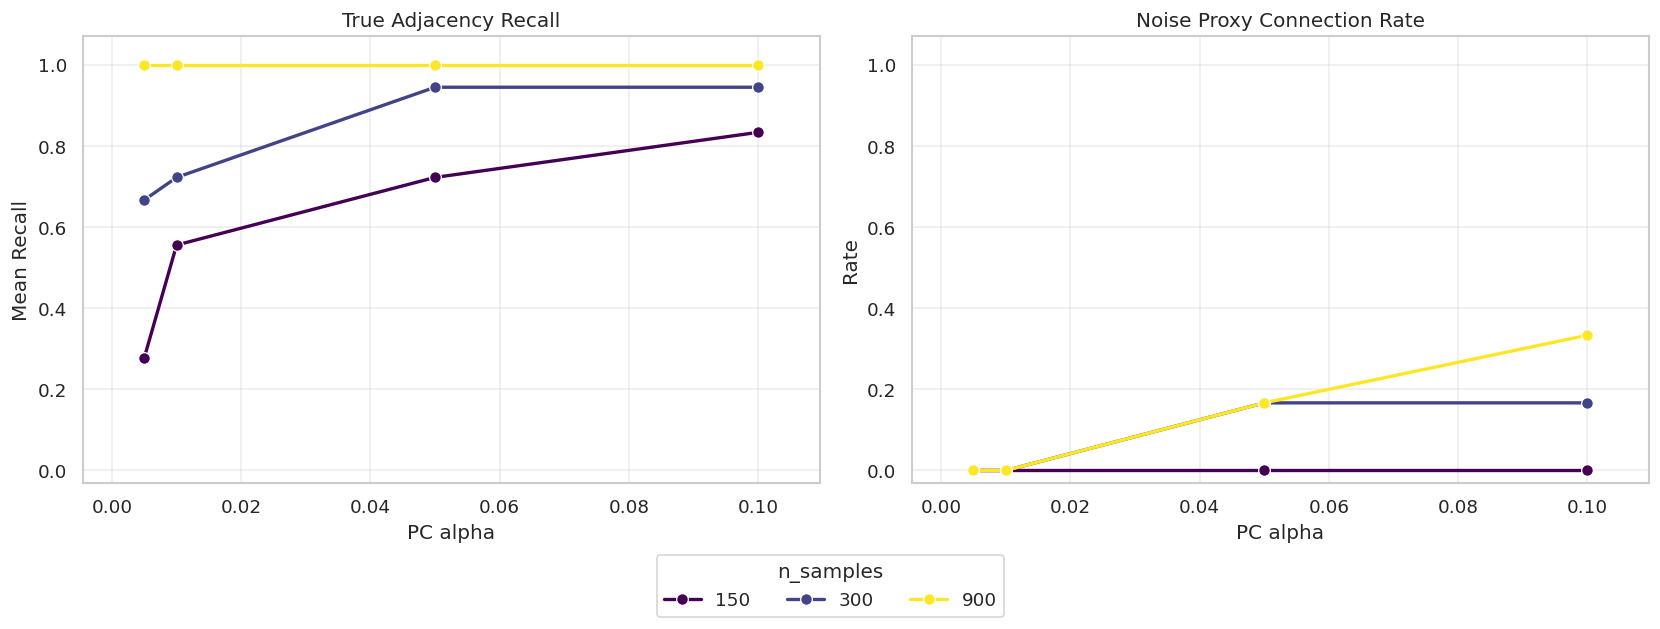

In [10]:
# Build and label the diagnostic visualization for the Lab 2: Weak Tests And Small Samples section.
alpha_min = weak_sensitivity_summary["alpha"].min()
alpha_max = weak_sensitivity_summary["alpha"].max()
alpha_pad = (alpha_max - alpha_min) * 0.10

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharex=True)

sns.lineplot(
    data=weak_sensitivity_summary,
    x="alpha",
    y="mean_skeleton_recall",
    hue="n_samples",
    marker="o",
    markersize=7,
    linewidth=2,
    palette="viridis",
    ax=axes[0],
)
axes[0].set_title("True Adjacency Recall")
axes[0].set_xlabel("PC alpha")
axes[0].set_ylabel("Mean Recall")
axes[0].set_ylim(-0.03, 1.07)

sns.lineplot(
    data=weak_sensitivity_summary,
    x="alpha",
    y="proxy_connection_rate",
    hue="n_samples",
    marker="o",
    markersize=7,
    linewidth=2,
    palette="viridis",
    ax=axes[1],
)
axes[1].set_title("Noise Proxy Connection Rate")
axes[1].set_xlabel("PC alpha")
axes[1].set_ylabel("Rate")
axes[1].set_ylim(-0.03, 1.07)

for ax in axes:
    ax.set_xlim(alpha_min - alpha_pad, alpha_max + alpha_pad)
    ax.grid(True, alpha=0.35)

handles, labels = axes[0].get_legend_handles_labels()
for ax in axes:
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

fig.legend(
    handles,
    labels,
    title="n_samples",
    loc="lower center",
    ncol=len(labels),
    frameon=True,
    bbox_to_anchor=(0.5, -0.02),
)
fig.tight_layout(rect=(0, 0.08, 1, 1))
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_weak_signal_sensitivity.png", dpi=160, bbox_inches="tight")
plt.show()


The plot makes the tradeoff visible. A setting that recovers more weak signal can also admit more noise. The responsible move is to report this tradeoff and avoid making edge-by-edge claims from one arbitrary alpha.

### Lab 3: Markov Equivalence and Over-Orientation

A skeleton can be well supported while some directions remain ambiguous. The chain `A -> B -> C` and the fork `A <- B -> C` both imply that `A` and `C` become independent after conditioning on `B`. Conditional-independence evidence alone cannot always choose between these structures.

This lab computes marginal and conditional association for both structures and then shows the shared partially directed story.

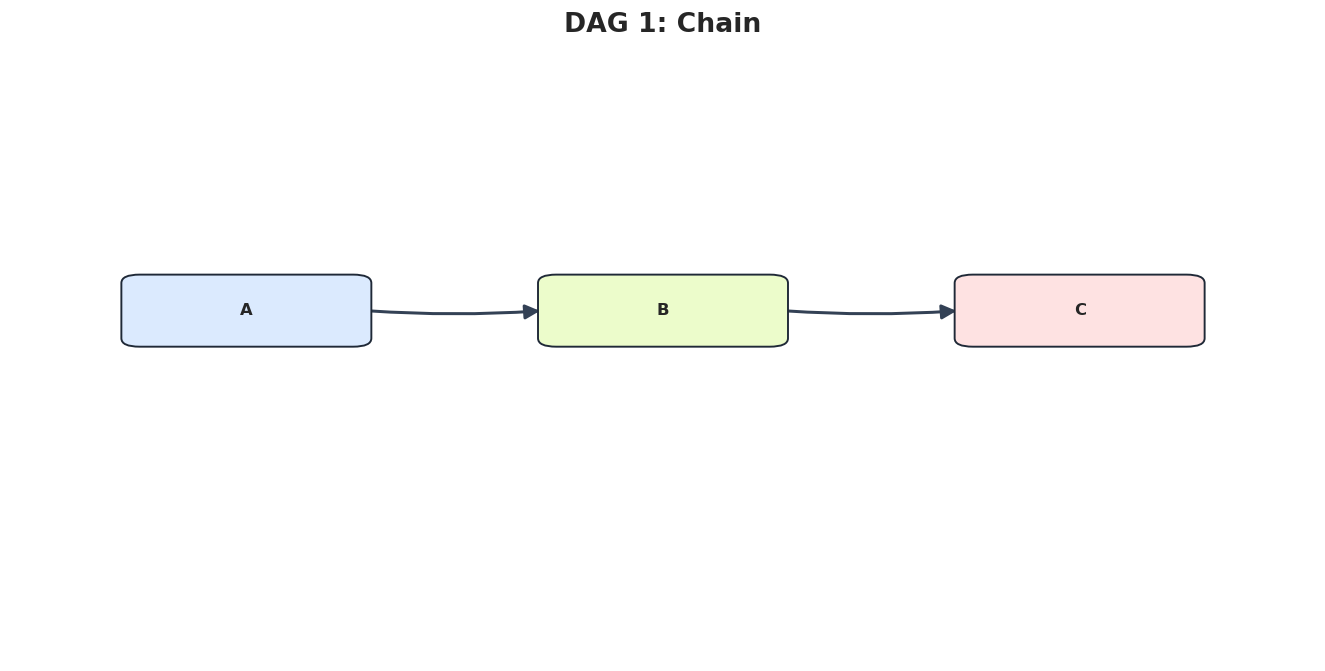

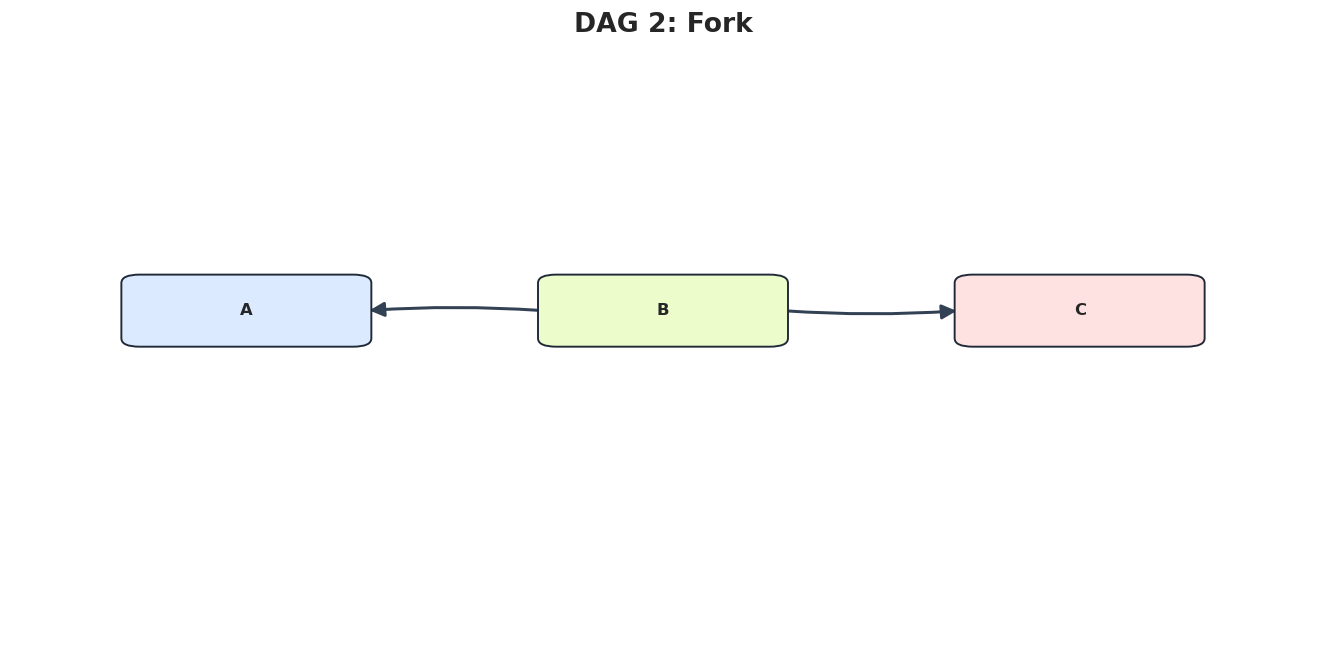

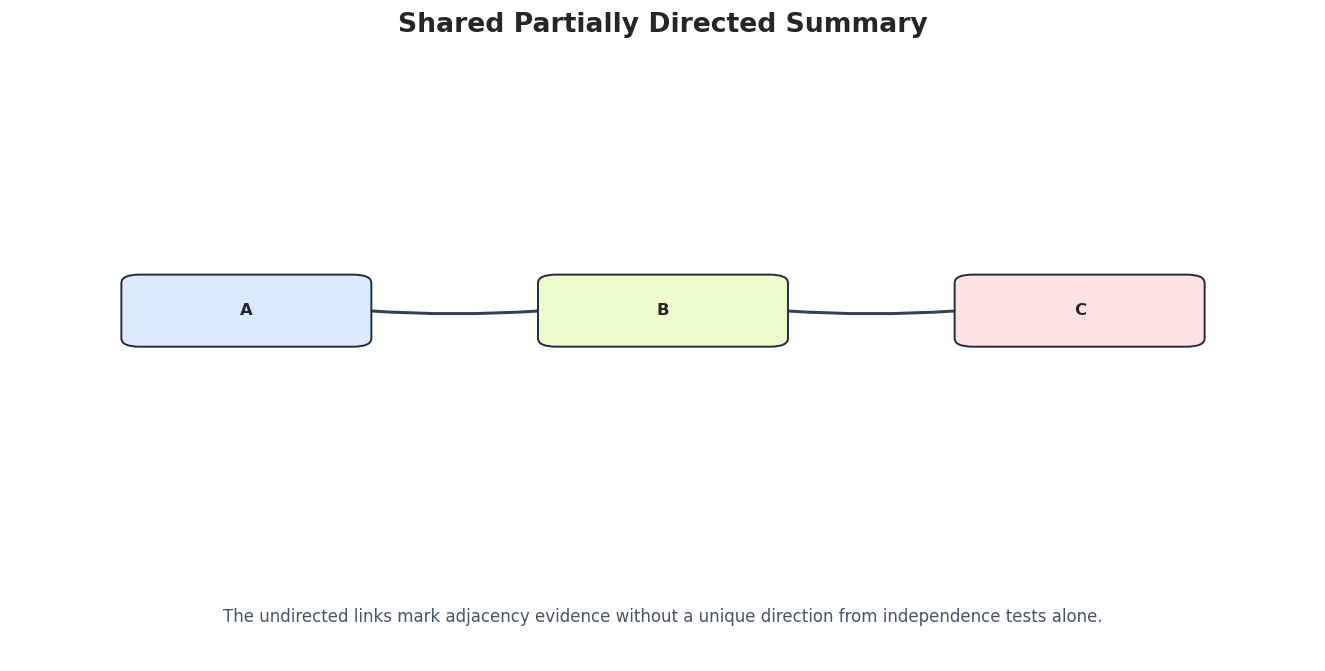

In [11]:
equiv_specs = {
    "A": {"xy": (0.18, 0.58), "label": "A", "color": "#dbeafe"},
    "B": {"xy": (0.50, 0.58), "label": "B", "color": "#ecfccb"},
    "C": {"xy": (0.82, 0.58), "label": "C", "color": "#fee2e2"},
}
chain_edges = make_edge_table([("A", "-->", "B"), ("B", "-->", "C")], run="chain")
fork_edges = make_edge_table([("B", "-->", "A"), ("B", "-->", "C")], run="fork")
cpdag_edges = make_edge_table([("A", "---", "B"), ("B", "---", "C")], run="shared_cpdag")

chain_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_equivalence_chain_edges.csv", index=False)
fork_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_equivalence_fork_edges.csv", index=False)
cpdag_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_equivalence_shared_cpdag_edges.csv", index=False)

draw_box_graph(chain_edges, equiv_specs, "DAG 1: Chain", FIGURE_DIR / f"{NOTEBOOK_PREFIX}_equivalence_chain.png")
draw_box_graph(fork_edges, equiv_specs, "DAG 2: Fork", FIGURE_DIR / f"{NOTEBOOK_PREFIX}_equivalence_fork.png")
draw_box_graph(
    cpdag_edges,
    equiv_specs,
    "Shared Partially Directed Summary",
    FIGURE_DIR / f"{NOTEBOOK_PREFIX}_equivalence_shared_cpdag.png",
    note="The undirected links mark adjacency evidence without a unique direction from independence tests alone.",
)


The two DAGs disagree about the direction between `A` and `B`, but their conditional-independence signature is the same for this simple three-node pattern. The partially directed summary is the safer graph to report when direction is not identified.

The code below simulates both structures and estimates the marginal correlation between `A` and `C`, plus the partial correlation after removing linear dependence on `B`. In both cases, conditioning on `B` removes the `A` and `C` association.

In [12]:
# Define reusable helpers for the Lab 3: Markov Equivalence And Over-Orientation section.
def residual_after_control(y, x):
    """
    Idea: Compute residual variation in one variable after adjusting for another variable.
    
    Parameters
    ----------
    y : str or array-like
        Outcome, second variable, or numeric input in the comparison.
    x : str or array-like
        First variable, column name, or numeric input in the comparison.
    
    Returns
    -------
    np.ndarray
        Target residuals after removing the linear contribution of the control variable.
    """
    design = np.column_stack([np.ones(len(x)), x])
    coef = np.linalg.lstsq(design, y, rcond=None)[0]
    return y - design @ coef


def partial_corr_ac_given_b(df):
    """
    Idea: Compute the partial correlation between two variables after removing the linear contribution of a conditioning variable.
    
    Parameters
    ----------
    df : pd.DataFrame
        Rows used by this helper.
    
    Returns
    -------
    float
        Partial correlation between two variables after adjusting for the conditioning variable.
    """
    a_resid = residual_after_control(df["A"].to_numpy(), df["B"].to_numpy())
    c_resid = residual_after_control(df["C"].to_numpy(), df["B"].to_numpy())
    return np.corrcoef(a_resid, c_resid)[0, 1]


def simulate_chain(seed, n_samples=1500):
    """
    Idea: Simulate the chain scenario so the notebook can study a known causal or statistical failure mode.
    
    Parameters
    ----------
    seed : int
        Random seed used to make generation or resampling reproducible.
    n_samples : int
        Number of sampled rows or simulated units.
    
    Returns
    -------
    pd.DataFrame
        Synthetic chain-structure dataset used to study path blocking and indirect dependence.
    """
    rng = np.random.default_rng(seed)
    a = rng.normal(size=n_samples)
    b = 0.85 * a + rng.normal(scale=0.80, size=n_samples)
    c = 0.85 * b + rng.normal(scale=0.80, size=n_samples)
    return standardize_frame(pd.DataFrame({"A": a, "B": b, "C": c}))


def simulate_fork(seed, n_samples=1500):
    """
    Idea: Simulate the fork scenario so the notebook can study a known causal or statistical failure mode.
    
    Parameters
    ----------
    seed : int
        Random seed used to make generation or resampling reproducible.
    n_samples : int
        Number of sampled rows or simulated units.
    
    Returns
    -------
    pd.DataFrame
        Synthetic fork-structure dataset used to study common-cause dependence.
    """
    rng = np.random.default_rng(seed)
    b = rng.normal(size=n_samples)
    a = 0.85 * b + rng.normal(scale=0.80, size=n_samples)
    c = 0.85 * b + rng.normal(scale=0.80, size=n_samples)
    return standardize_frame(pd.DataFrame({"A": a, "B": b, "C": c}))

chain_df = simulate_chain(RANDOM_SEED)
fork_df = simulate_fork(RANDOM_SEED)
chain_df.to_csv(DATASET_DIR / f"{NOTEBOOK_PREFIX}_equivalence_chain_data.csv", index=False)
fork_df.to_csv(DATASET_DIR / f"{NOTEBOOK_PREFIX}_equivalence_fork_data.csv", index=False)

equiv_stats = pd.DataFrame(
    [
        {
            "scenario": "chain_A_to_B_to_C",
            "corr_A_C": chain_df[["A", "C"]].corr().iloc[0, 1],
            "partial_corr_A_C_given_B": partial_corr_ac_given_b(chain_df),
        },
        {
            "scenario": "fork_B_to_A_and_C",
            "corr_A_C": fork_df[["A", "C"]].corr().iloc[0, 1],
            "partial_corr_A_C_given_B": partial_corr_ac_given_b(fork_df),
        },
    ]
)
equiv_stats.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_markov_equivalence_stats.csv", index=False)
display(equiv_stats.round(4))


,scenario,corr_A_C,partial_corr_A_C_given_B
0,chain_A_to_B_to_C,0.5570,-0.0355
1,fork_B_to_A_and_C,0.5489,0.0418


The conditional association is near zero in both scenarios. This is the mathematical reason over-orientation is dangerous: the data can support adjacency without uniquely supporting a direction.

Now we run PC on the two equivalent datasets. The exact edge marks can vary by implementation details, but the key lesson is that the evidence is about a shared equivalence class, not a guaranteed unique DAG.

In [13]:
chain_pc_edges, chain_pc_elapsed = run_pc_edges(chain_df, alpha=0.01, label="PC_chain_data")
fork_pc_edges, fork_pc_elapsed = run_pc_edges(fork_df, alpha=0.01, label="PC_fork_data")
equiv_pc_edges = pd.concat([chain_pc_edges, fork_pc_edges], ignore_index=True)
equiv_pc_edges["elapsed_seconds"] = equiv_pc_edges["run"].map(
    {"PC_chain_data": chain_pc_elapsed, "PC_fork_data": fork_pc_elapsed}
)
equiv_pc_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_markov_equivalence_pc_edges.csv", index=False)
display(equiv_pc_edges)

,run,source,edge_type,target,elapsed_seconds
0,PC_chain_data,A,---,B,0.001806
1,PC_chain_data,B,---,C,0.001806
2,PC_fork_data,A,---,B,0.001460
3,PC_fork_data,B,---,C,0.001460


The safe reporting habit is to separate adjacency evidence from direction evidence. If a direction is coming from timing, background knowledge, or an algorithm-specific assumption, say that explicitly.

#### Lab 4: Temporal Leakage

Temporal leakage happens when variables measured after the target event are included as if they were pre-event causes. In discovery workflows, this can make a graph look strong while quietly mixing causes, outcomes, and consequences.

The synthetic truth below includes `post_event_activity`, which is generated after `retention_value`. It should not be used to discover pre-retention causes.

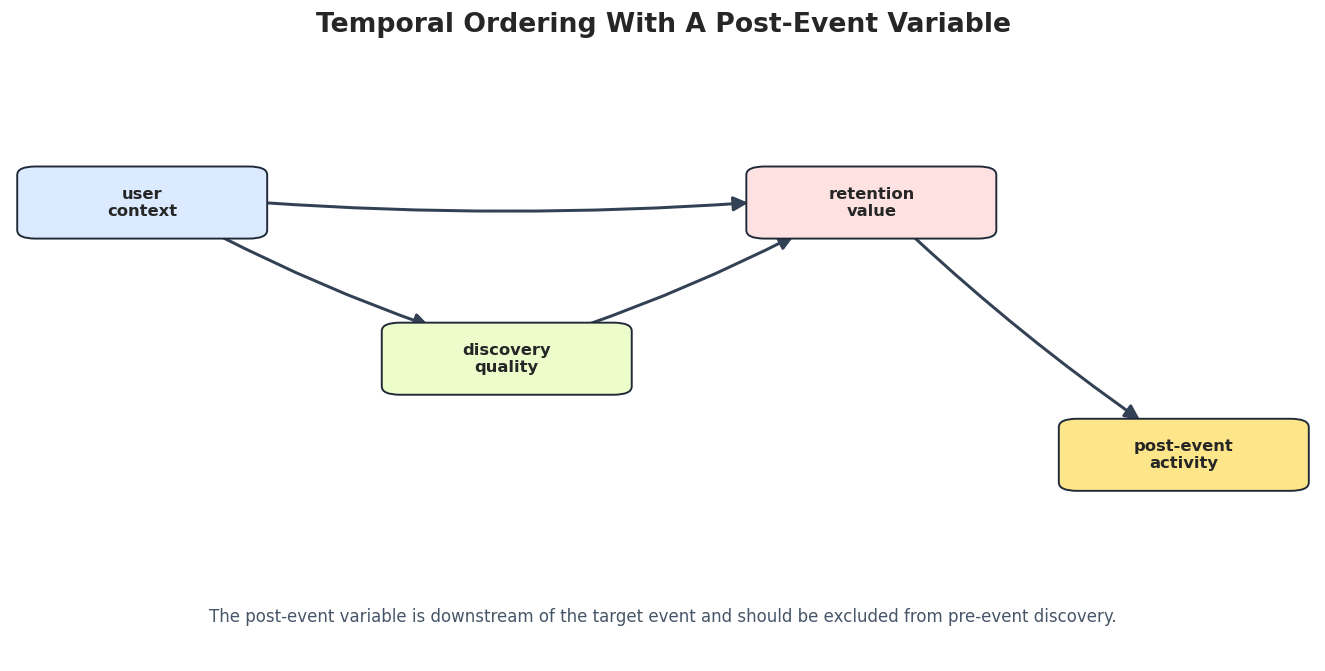

In [14]:
leak_specs = {
    "user_context": {"xy": (0.10, 0.76), "label": "user\ncontext", "color": "#dbeafe"},
    "discovery_quality": {"xy": (0.38, 0.50), "label": "discovery\nquality", "color": "#ecfccb"},
    "retention_value": {"xy": (0.66, 0.76), "label": "retention\nvalue", "color": "#fee2e2"},
    "post_event_activity": {"xy": (0.90, 0.34), "label": "post-event\nactivity", "color": "#fde68a"},
}
leak_truth_edges = make_edge_table(
    [
        ("user_context", "-->", "discovery_quality"),
        ("user_context", "-->", "retention_value"),
        ("discovery_quality", "-->", "retention_value"),
        ("retention_value", "-->", "post_event_activity"),
    ],
    run="temporal_truth",
)
leak_truth_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_temporal_leakage_truth_edges.csv", index=False)

draw_box_graph(
    leak_truth_edges,
    leak_specs,
    "Temporal Ordering With A Post-Event Variable",
    FIGURE_DIR / f"{NOTEBOOK_PREFIX}_temporal_leakage_truth.png",
    note="The post-event variable is downstream of the target event and should be excluded from pre-event discovery.",
)


The graph gives a clear exclusion rule: `post_event_activity` is useful for describing what happened later, but it is not a valid pre-retention cause. A measurement-time table should catch this before any algorithm runs.

The code below simulates the temporal-leakage scenario and writes the measurement timing table. The timing table is often more valuable than another algorithm tweak because it prevents invalid variables from entering the problem.

In [15]:
# Define reusable helpers for the Lab 4: Temporal Leakage section.
def simulate_temporal_leakage(n_samples=900, seed=RANDOM_SEED):
    """
    Idea: Simulate the temporal leakage scenario so the notebook can study a known causal or statistical failure mode.
    
    Parameters
    ----------
    n_samples : int
        Number of sampled rows or simulated units.
    seed : int
        Random seed used to make generation or resampling reproducible.
    
    Returns
    -------
    pd.DataFrame
        Dataset with future-looking leakage variables for the temporal-ordering pitfall.
    """
    rng = np.random.default_rng(seed)
    user_context = rng.normal(size=n_samples)
    discovery_quality = 0.75 * user_context + rng.normal(scale=0.80, size=n_samples)
    retention_value = 0.35 * user_context + 0.75 * discovery_quality + rng.normal(scale=0.80, size=n_samples)
    post_event_activity = 0.90 * retention_value + rng.normal(scale=0.65, size=n_samples)
    df = pd.DataFrame(
        {
            "user_context": user_context,
            "discovery_quality": discovery_quality,
            "retention_value": retention_value,
            "post_event_activity": post_event_activity,
        }
    )
    return standardize_frame(df)

leak_df = simulate_temporal_leakage()
leak_df.to_csv(DATASET_DIR / f"{NOTEBOOK_PREFIX}_temporal_leakage_data.csv", index=False)

measurement_timing = pd.DataFrame(
    [
        {"variable": "user_context", "measurement_window": "before discovery", "allowed_for_pre_retention_discovery": True},
        {"variable": "discovery_quality", "measurement_window": "during discovery", "allowed_for_pre_retention_discovery": True},
        {"variable": "retention_value", "measurement_window": "target event", "allowed_for_pre_retention_discovery": True},
        {"variable": "post_event_activity", "measurement_window": "after target event", "allowed_for_pre_retention_discovery": False},
    ]
)
measurement_timing.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_measurement_timing_table.csv", index=False)
display(measurement_timing)


,variable,measurement_window,allowed_for_pre_retention_discovery
0,user_context,before discovery,True
1,discovery_quality,during discovery,True
2,retention_value,target event,True
3,post_event_activity,after target event,False


The table turns a subtle modeling issue into an auditable rule. Any variable marked as measured after the target event should be excluded from discovery runs meant to explain pre-event causes.

Now we compare a clean run that excludes the post-event variable with a leaky run that includes it. The leaky run is not useful because it mixes a future consequence into the discovery target.

In [16]:
clean_leak_df = leak_df[["user_context", "discovery_quality", "retention_value"]].copy()
leaky_leak_df = leak_df.copy()

clean_leak_edges, clean_leak_elapsed = run_pc_edges(clean_leak_df, alpha=0.01, label="PC_clean_timing")
leaky_leak_edges, leaky_leak_elapsed = run_pc_edges(leaky_leak_df, alpha=0.01, label="PC_with_post_event_variable")
leak_pc_edges = pd.concat([clean_leak_edges, leaky_leak_edges], ignore_index=True)
leak_pc_edges["elapsed_seconds"] = leak_pc_edges["run"].map(
    {"PC_clean_timing": clean_leak_elapsed, "PC_with_post_event_variable": leaky_leak_elapsed}
)
leak_pc_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_temporal_leakage_pc_edges.csv", index=False)
display(leak_pc_edges)

,run,source,edge_type,target,elapsed_seconds
0,PC_clean_timing,user_context,---,discovery_quality,0.001721
1,PC_clean_timing,user_context,---,retention_value,0.001721
2,PC_clean_timing,discovery_quality,---,retention_value,0.001721
3,PC_with_post_event_variable,user_context,---,discovery_quality,0.003029
4,PC_with_post_event_variable,user_context,---,retention_value,0.003029
5,PC_with_post_event_variable,discovery_quality,---,retention_value,0.003029
6,PC_with_post_event_variable,retention_value,---,post_event_activity,0.003029


The run with the post-event variable may look richer, but that richness is misleading for causal discovery about pre-event drivers. More variables are not automatically better when their timestamps are wrong.

#### Lab 5: Selection Bias from Conditioning on a Collider

Selection bias appears when the analysis dataset includes only cases that passed through a selection mechanism. If selection is influenced by two variables, filtering on selection can make those variables dependent even when neither causes the other.

Here `interest` and `difficulty` both affect whether a case is selected. In the full population they are independent. In the selected sample, they become associated.

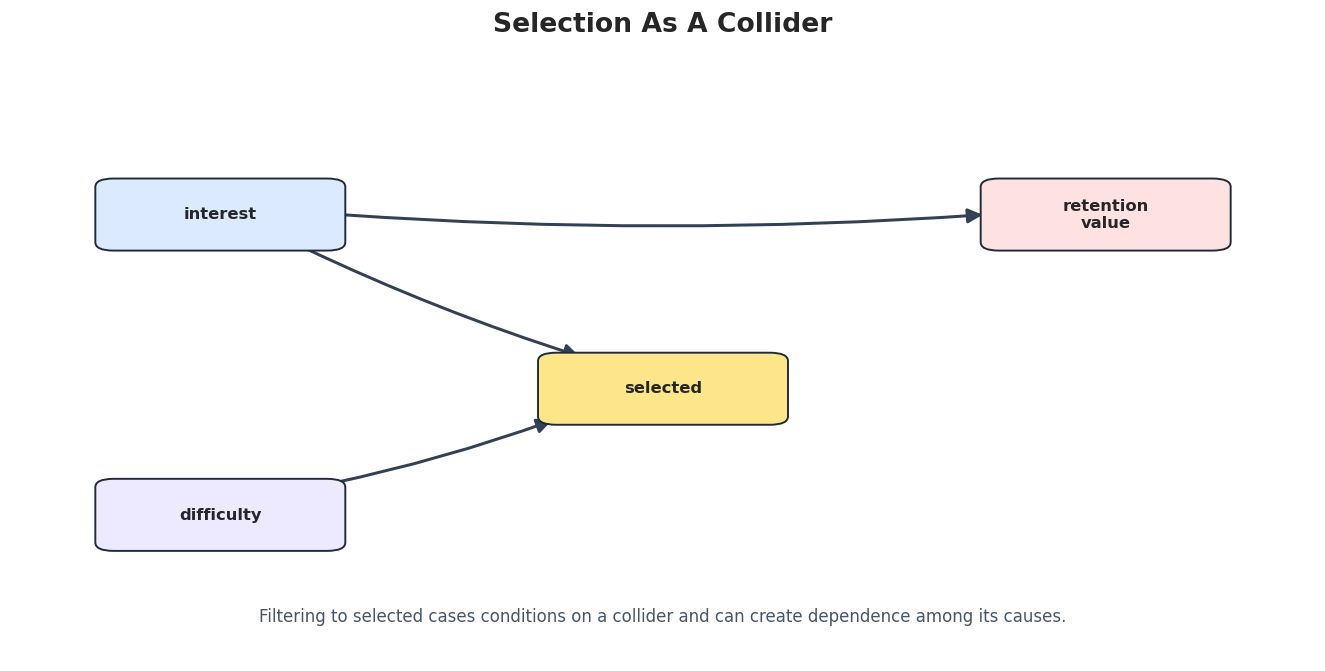

In [17]:
selection_specs = {
    "interest": {"xy": (0.16, 0.74), "label": "interest", "color": "#dbeafe"},
    "difficulty": {"xy": (0.16, 0.24), "label": "difficulty", "color": "#ede9fe"},
    "selected": {"xy": (0.50, 0.45), "label": "selected", "color": "#fde68a"},
    "retention_value": {"xy": (0.84, 0.74), "label": "retention\nvalue", "color": "#fee2e2"},
}
selection_truth_edges = make_edge_table(
    [
        ("interest", "-->", "selected"),
        ("difficulty", "-->", "selected"),
        ("interest", "-->", "retention_value"),
    ],
    run="selection_truth",
)
selection_truth_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_selection_bias_truth_edges.csv", index=False)

draw_box_graph(
    selection_truth_edges,
    selection_specs,
    "Selection As A Collider",
    FIGURE_DIR / f"{NOTEBOOK_PREFIX}_selection_bias_truth.png",
    note="Filtering to selected cases conditions on a collider and can create dependence among its causes.",
)


The warning sign is the collider: `interest -> selected <- difficulty`. Once we restrict the dataset to selected cases, `interest` and `difficulty` can become statistically linked even without a direct edge.

The code below simulates the full population and a selected subset. The selection rule keeps cases with high combined interest and difficulty, reproducing a common filtered-data pattern.

In [18]:
# Define reusable helpers for the Lab 5: Selection Bias From Conditioning On A Collider section.
def simulate_selection_bias(n_samples=5000, seed=RANDOM_SEED):
    """
    Idea: Simulate the selection bias scenario so the notebook can study a known causal or statistical failure mode.
    
    Parameters
    ----------
    n_samples : int
        Number of sampled rows or simulated units.
    seed : int
        Random seed used to make generation or resampling reproducible.
    
    Returns
    -------
    tuple
        Tuple containing standardize_frame(full_df), standardize_frame(selected_df).
    """
    rng = np.random.default_rng(seed)
    interest = rng.normal(size=n_samples)
    difficulty = rng.normal(size=n_samples)
    selection_score = 0.90 * interest + 0.90 * difficulty + rng.normal(scale=0.65, size=n_samples)
    threshold = np.quantile(selection_score, 0.68)
    selected = selection_score > threshold
    retention_value = 0.70 * interest + rng.normal(scale=0.90, size=n_samples)
    full_df = pd.DataFrame(
        {
            "interest": interest,
            "difficulty": difficulty,
            "selected": selected.astype(int),
            "retention_value": retention_value,
        }
    )
    selected_df = full_df.loc[selected, ["interest", "difficulty", "retention_value"]].reset_index(drop=True)
    return standardize_frame(full_df), standardize_frame(selected_df)

selection_full_df, selection_selected_df = simulate_selection_bias()
selection_full_df.to_csv(DATASET_DIR / f"{NOTEBOOK_PREFIX}_selection_bias_full_data.csv", index=False)
selection_selected_df.to_csv(DATASET_DIR / f"{NOTEBOOK_PREFIX}_selection_bias_selected_data.csv", index=False)

print(f"Full population shape: {selection_full_df.shape}")
print(f"Selected sample shape: {selection_selected_df.shape}")


Full population shape: (5000, 4)
Selected sample shape: (1600, 3)


The selected sample is a biased slice of the full population. Any graph learned only from this slice describes that filtered dataset, not necessarily the population mechanism.

The next cell quantifies the induced dependence. It compares the correlation between `interest` and `difficulty` in the full population versus the selected sample.

In [19]:
selection_correlation_summary = pd.DataFrame(
    [
        {
            "sample": "full_population",
            "n_rows": len(selection_full_df),
            "corr_interest_difficulty": selection_full_df[["interest", "difficulty"]].corr().iloc[0, 1],
        },
        {
            "sample": "selected_only",
            "n_rows": len(selection_selected_df),
            "corr_interest_difficulty": selection_selected_df[["interest", "difficulty"]].corr().iloc[0, 1],
        },
    ]
)
selection_correlation_summary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_selection_bias_correlation_summary.csv", index=False)
display(selection_correlation_summary.round(4))


,sample,n_rows,corr_interest_difficulty
0,full_population,5000,-0.0337
1,selected_only,1600,-0.4256


A near-zero population association can turn into a strong selected-sample association. This is why reports must describe how rows entered the dataset, more than which columns were used.

Finally, we run PC on the selected sample. If the algorithm connects `interest` and `difficulty`, that edge is a selection output candidate rather than a clean causal mechanism.


In [20]:
selection_pc_edges, selection_pc_elapsed = run_pc_edges(selection_selected_df, alpha=0.01, label="PC_selected_sample")
selection_pc_edges["elapsed_seconds"] = selection_pc_elapsed
selection_pc_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_selection_bias_pc_edges.csv", index=False)
display(selection_pc_edges)

,run,source,edge_type,target,elapsed_seconds
0,PC_selected_sample,interest,---,difficulty,0.001835
1,PC_selected_sample,interest,---,retention_value,0.001835


The practical lesson is to document inclusion rules. If a dataset is restricted to responders, active users, retained customers, completed sessions, or any selected subset, collider bias should be on the checklist.

#### Lab 6: Near-Duplicate Measurements

Discovery algorithms operate on columns. If two columns are near-duplicates of the same construct, the graph may spend edges explaining measurement redundancy instead of the causal system.

This lab creates a true causal chain and then adds a duplicate proxy for the middle variable.

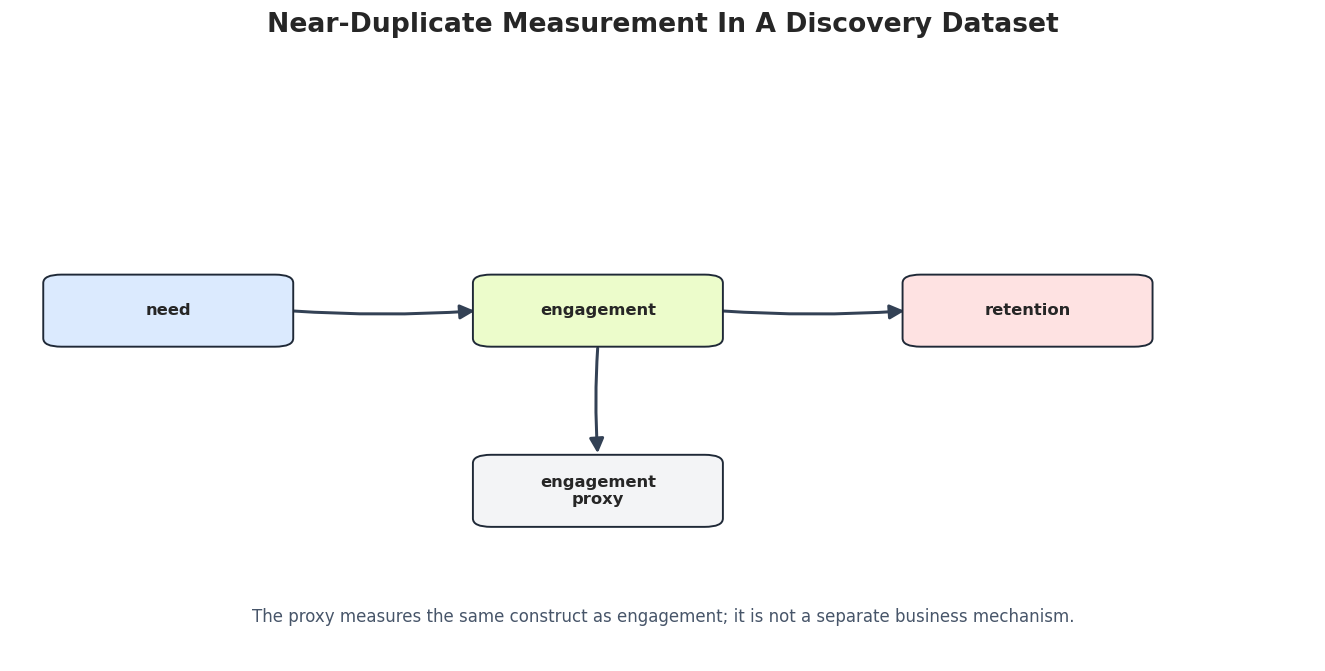

In [21]:
duplicate_specs = {
    "need": {"xy": (0.12, 0.58), "label": "need", "color": "#dbeafe"},
    "engagement": {"xy": (0.45, 0.58), "label": "engagement", "color": "#ecfccb"},
    "engagement_proxy": {"xy": (0.45, 0.28), "label": "engagement\nproxy", "color": "#f3f4f6"},
    "retention": {"xy": (0.78, 0.58), "label": "retention", "color": "#fee2e2"},
}
duplicate_truth_edges = make_edge_table(
    [
        ("need", "-->", "engagement"),
        ("engagement", "-->", "retention"),
        ("engagement", "-->", "engagement_proxy"),
    ],
    run="duplicate_measurement_truth",
)
duplicate_truth_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_duplicate_measurement_truth_edges.csv", index=False)

draw_box_graph(
    duplicate_truth_edges,
    duplicate_specs,
    "Near-Duplicate Measurement In A Discovery Dataset",
    FIGURE_DIR / f"{NOTEBOOK_PREFIX}_duplicate_measurement_truth.png",
    note="The proxy measures the same construct as engagement; it is not a separate business mechanism.",
)


The proxy is downstream of the same latent concept represented by `engagement`. Without careful feature review, the graph can make this measurement relationship look as important as the mechanism of interest.

This simulator creates a proxy that is almost a copy of `engagement`. The correlation audit will flag that relationship before we read the discovery graph.

In [22]:
# Define reusable helpers for the Lab 6: Near-Duplicate Measurements section.
def simulate_duplicate_measurement(n_samples=900, seed=RANDOM_SEED):
    """
    Idea: Simulate the duplicate measurement scenario so the notebook can study a known causal or statistical failure mode.
    
    Parameters
    ----------
    n_samples : int
        Number of sampled rows or simulated units.
    seed : int
        Random seed used to make generation or resampling reproducible.
    
    Returns
    -------
    pd.DataFrame
        Dataset with duplicate or near-duplicate measurements that can distort discovery output.
    """
    rng = np.random.default_rng(seed)
    need = rng.normal(size=n_samples)
    engagement = 0.85 * need + rng.normal(scale=0.70, size=n_samples)
    engagement_proxy = engagement + rng.normal(scale=0.10, size=n_samples)
    retention = 0.75 * engagement + rng.normal(scale=0.75, size=n_samples)
    df = pd.DataFrame(
        {
            "need": need,
            "engagement": engagement,
            "engagement_proxy": engagement_proxy,
            "retention": retention,
        }
    )
    return standardize_frame(df)

duplicate_df = simulate_duplicate_measurement()
duplicate_df.to_csv(DATASET_DIR / f"{NOTEBOOK_PREFIX}_duplicate_measurement_data.csv", index=False)

duplicate_corr = duplicate_df.corr()
duplicate_corr.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_duplicate_measurement_correlation_matrix.csv")

duplicate_pairs = []
for i, left in enumerate(duplicate_corr.columns):
    for right in duplicate_corr.columns[i + 1:]:
        duplicate_pairs.append(
            {
                "left_variable": left,
                "right_variable": right,
                "abs_correlation": abs(duplicate_corr.loc[left, right]),
                "near_duplicate_flag": abs(duplicate_corr.loc[left, right]) >= 0.90,
            }
        )
duplicate_pair_audit = pd.DataFrame(duplicate_pairs).sort_values("abs_correlation", ascending=False)
duplicate_pair_audit.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_duplicate_measurement_pair_audit.csv", index=False)
display(duplicate_pair_audit.round(4))


,left_variable,right_variable,abs_correlation,near_duplicate_flag
3,engagement,engagement_proxy,0.9959,True
0,need,engagement,0.7640,False
1,need,engagement_proxy,0.7607,False
4,engagement,retention,0.7579,False
5,engagement_proxy,retention,0.7563,False
2,need,retention,0.5812,False


The near-duplicate flag is a warning to pause before discovery. Highly redundant variables may need to be collapsed, grouped, or documented as measurement proxies.

The next code block runs PC on the duplicate-measurement data. The algorithm is doing what the columns ask it to do. The responsibility is on us to design variables that match the causal question.

In [23]:
duplicate_pc_edges, duplicate_pc_elapsed = run_pc_edges(duplicate_df, alpha=0.01, label="PC_with_duplicate_proxy")
duplicate_pc_edges["elapsed_seconds"] = duplicate_pc_elapsed
duplicate_pc_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_duplicate_measurement_pc_edges.csv", index=False)
display(duplicate_pc_edges)

,run,source,edge_type,target,elapsed_seconds
0,PC_with_duplicate_proxy,need,---,engagement,0.003427
1,PC_with_duplicate_proxy,engagement,---,engagement_proxy,0.003427


If a near-duplicate edge appears, it should usually be reported as a measurement issue rather than a substantive causal discovery. This is a good example of why feature engineering review belongs in causal discovery.



#### Reporting Language Ladder

The examples above all point to a language problem: a discovered graph often looks more certain than it is. This table gives a practical ladder of claims, from safest to strongest. Stronger language requires stronger validation.

| claim_level | example_language | minimum_support_needed |
| --- | --- | --- |
| association pattern | These variables are connected in the observed-data graph. | Clean data audit and a transparent discovery run. |
| stable candidate edge | This edge is a stable candidate across sensitivity checks. | Bootstrap, alpha, sample-split, or method-comparison support. |
| direction supported by assumptions | The direction is supported under the stated timing and algorithm assumptions. | Documented measurement order, background knowledge, and algorithm assumptions. |
| causal mechanism hypothesis | This path is a plausible mechanism to validate next. | Stable graph evidence plus domain review and a validation plan. |
| decision-ready causal claim | Changing this variable is expected to change the outcome by this amount. | An experiment, quasi-experiment, or effect-estimation design beyond graph discovery alone. |


A useful discovery report usually lives in the middle of this ladder. It can identify stable candidate mechanisms and prioritize follow-up work without pretending the graph alone estimates intervention effects.

#### Reporting Checklist

The checklist below turns the notebook into a reusable review output. Before sharing a discovered graph, each row should have an answer. If an answer is missing, the report should say so directly.


| category | check | why_it_matters |
| --- | --- | --- |
| Question | Is the causal discovery target stated in plain language? | Avoids drifting from exploration to overclaiming. |
| Variables | Does every variable have a definition and measurement window? | Prevents temporal leakage and mixed-granularity graphs. |
| Rows | Is the sampling or selection rule documented? | Makes selection bias visible. |
| Assumptions | Are sufficiency, faithfulness, stationarity, and functional assumptions stated? | Connects algorithms to the conditions they need. |
| Algorithms | Are algorithm settings, tests, scores, and package versions saved? | Makes the run reproducible. |
| Stability | Were alpha, sample, seed, threshold, or method sensitivity checks run? | Separates stable candidates from fragile edges. |
| Hidden causes | Were plausible omitted common causes reviewed? | Protects against reading confounded links as direct effects. |
| Graph reading | Are adjacencies, directions, and equivalence-class limits separated? | Reduces over-orientation. |
| Validation | Is there a proposed experiment, quasi-experiment, or effect-estimation follow-up? | Moves from graph hypotheses to causal evidence. |
| Communication | Does the report use cautious language for candidate edges? | Keeps the audience from treating discovery as proof. |


The checklist is intentionally operational. It is meant to be used before a graph appears in a slide, report, notebook summary, or handoff document.

#### A Reusable Report Template

This final code cell writes a markdown template. The template gives students and practitioners a starting point for communicating discovery results without overstating them.

In [24]:
report_template = """# Causal Discovery Report Template

## 1. Discovery Question

State the graph question in one or two sentences. Name the decision, mechanism, or scientific question the graph is meant to inform.

## 2. Data Scope

- Row unit:
- Time period:
- Inclusion and exclusion rules:
- Known selection mechanisms:
- Missingness handling:

## 3. Variable Dictionary

For each variable, include definition, measurement window, allowed causal timing tier, and whether it is an input, mechanism, outcome, or post-outcome measure.

## 4. Assumptions

State which assumptions are required by the chosen methods. Include causal sufficiency, faithfulness, stationarity, linearity, non-Gaussianity, or functional-form assumptions where relevant.

## 5. Algorithms And Settings

List algorithms, independence tests or scores, alpha values, thresholds, background knowledge, package versions, and random seeds.

## 6. Main Candidate Graph

Show the graph and separate:

- stable adjacencies;
- directions supported by timing or method assumptions;
- ambiguous or equivalence-class edges;
- edges with plausible hidden-confounding risk.

## 7. Sensitivity Checks

Summarize sample-size, alpha, threshold, seed, bootstrap, method-comparison, and hidden-confounding checks.

## 8. Edge Review Table

For each important edge, report support level, caveats, plausible omitted causes, and recommended validation.

## 9. What The Graph Does Not Prove

State limits plainly. Graph discovery alone usually does not estimate intervention effects or prove that changing a variable will change the outcome.

## 10. Next Validation Step

Recommend the next experiment, quasi-experiment, effect-estimation design, or data collection step.
"""

report_path = REPORT_DIR / f"{NOTEBOOK_PREFIX}_causal_discovery_report_template.md"
report_path.write_text(report_template)
print(report_path)


/home/apex/Documents/portfolio/notebooks/tutorials/causal_learn/outputs/reports/17_causal_discovery_report_template.md


The template is the bridge from notebook work to communication. It nudges the report toward assumptions, stability, and validation rather than a single attractive graph.

The output list is also a useful final audit. If a report references a figure or table, it should appear here with a stable filename.


#### Closing Notes

The core lesson of this tutorial series is that causal discovery is a disciplined workflow, more than an algorithm call. The library can estimate candidate graph structure, but the analyst is responsible for defining variables, respecting time, checking assumptions, stress-testing output, and communicating uncertainty.

A strong discovery notebook leaves the reader with a graph, a list of caveats, a stability summary, and a validation plan. That combination is much more credible than a graph alone.